In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])


c:\Users\DELL\anaconda3\1\envs\py11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_jobs=pd.DataFrame({'job_id':[1,2,3,4,5],
                      'job_title':['Data Scientist','Software Engineer','Product Manager','Marketing Director','HR Manager'],
                      'company_name':['Google','Microsoft','Apple','Amazon','Facebook'],
                      'job_location':['Mountain View, CA','Redmond, WA','Cupertino, CA','Beaverton, OR','Seattle, WA']})


                                

In [3]:
df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Amazon,"Beaverton, OR"
4,5,HR Manager,Facebook,"Seattle, WA"


In [4]:
df_companies=pd.DataFrame({'company_name':['Google','Microsoft','Apple','Nike','Starbucks'],
                           'industry':['Technology','Technology','Technology','Apparel','Food & Beverage'],
                           'company_size':['100,000+','100,000+','100,000+','75,000+','346,000+']})

In [5]:
df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [6]:
df_jobs.merge(df_companies, on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"


In [14]:
df_US=df[df['job_country']=='United States'].copy()
df_US['job_posted_month']=df_US['job_posted_date'].dt.strftime('%B')
df_US_pivot=df_US.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')
df_US_pivot=df_US_pivot.reset_index()
df_US_pivot['job_posted_month_no']=pd.to_datetime(df_US_pivot['job_posted_month'],format='%B').dt.month
df_US_pivot=df_US_pivot.sort_values('job_posted_month_no')
df_US_pivot=df_US_pivot.set_index('job_posted_month')
df_US_pivot=df_US_pivot.drop(columns=['job_posted_month_no'])

df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [17]:
df_US_software_pivot=pd.read_csv('https://lukeb.co/software_csv', index_col='job_posted_month')
df_US_software_pivot


,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [23]:
df_US_merged=df_US_pivot.merge(df_US_software_pivot, on='job_posted_month')
df_US_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
September,897,50,4639,3224,4568,113,805,775,1014,228,14016,8447,6139,4094


In [ ]:
top_5=(
    df_US_merged
    .sum()
    .sort_values(ascending=False)
    .head()
    .index #index of top 5
    .to_list())
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

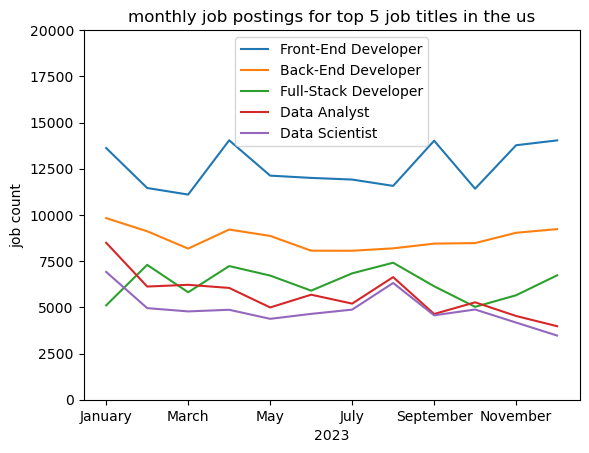

In [27]:
df_US_merged[top_5].plot(kind='line')
plt.title('monthly job postings for top 5 job titles in the us')
plt.xlabel('2023')
plt.ylabel('job count')
plt.ylim(0, 20000)
plt.legend()
plt.show()
